In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, roc_auc_score#,plot_roc_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
cosmos = pd.read_csv("neo.csv")
cosmos

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


In [29]:
cosmos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [30]:
cosmos.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [31]:
cosmos.isnull().sum() #sprawdzenie czy są jakieś puste rekordy

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [32]:
print(cosmos.nunique()) #sprawdzenie ile jest wartości unikalnych w każdej kolumnie 

id                    27423
name                  27423
est_diameter_min       1638
est_diameter_max       1638
relative_velocity     90828
miss_distance         90536
orbiting_body             1
sentry_object             1
absolute_magnitude     1638
hazardous                 2
dtype: int64


In [33]:
cosmos.head()


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [2]:
cosmos = cosmos.drop(['id','name','orbiting_body','sentry_object'], axis=1) #porzucenie kolumn
cosmos

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True
...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,25.00,False
90832,0.016771,0.037501,46114.605073,5.432121e+07,26.00,False
90833,0.031956,0.071456,7566.807732,2.840077e+07,24.60,False
90834,0.007321,0.016370,69199.154484,6.869206e+07,27.80,False


In [3]:
print("Number of hazardous/Non-hazardous objects: \n")
print(cosmos["hazardous"].value_counts())
print("")
print("Percentage of hazardous/Non-hazardous objects: \n")
print((cosmos["hazardous"].value_counts() / len(cosmos))*100)

Number of hazardous/Non-hazardous objects: 

hazardous
False    81996
True      8840
Name: count, dtype: int64

Percentage of hazardous/Non-hazardous objects: 

hazardous
False    90.268176
True      9.731824
Name: count, dtype: float64


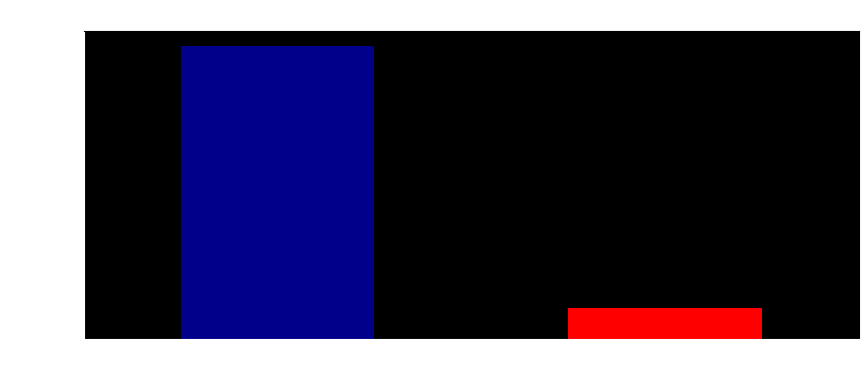

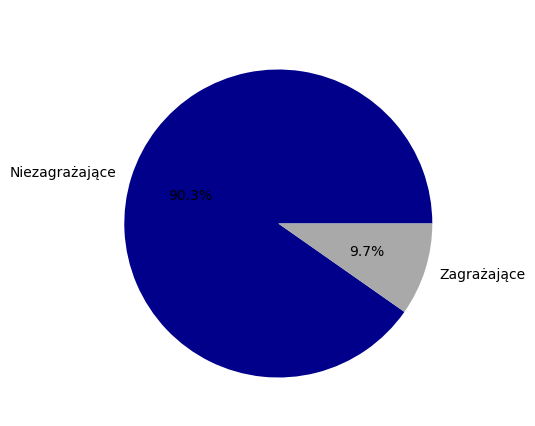

In [5]:
import matplotlib.pyplot as plt

# Assuming cosmos["hazardous"] contains the data
counts = cosmos["hazardous"].value_counts()
percentages = (counts / len(cosmos)) * 100

# Bar chart
plt.figure(figsize=(10, 4))
counts.plot(kind='bar', color=['darkblue', 'red'])
plt.title('Ilość obiektów zaklasyfikowanych jako niebezpieczne/ bezpieczne', color='white')
plt.xlabel('')
plt.ylabel('Ilość', color='white')
plt.xticks(ticks=[0, 1], labels=['Bezpieczne', 'Niebezpieczne'], rotation=0, color='white')
plt.yticks(color='white')
plt.gca().spines['bottom'].set_color('white')
plt.gca().spines['left'].set_color('white')
plt.gca().tick_params(axis='x', colors='white')
plt.gca().tick_params(axis='y', colors='white')
plt.gca().set_facecolor('black')
plt.show()

# Pie chart
plt.figure(figsize=(5, 5))
percentages.plot(kind='pie', autopct='%1.1f%%', colors=['darkblue', 'darkgrey'], labels=['Niezagrażające', 'Zagrażające'])
plt.title('Procent obiektów zagrażających i nie-zagrażających', color='white')
plt.ylabel('')
plt.gca().set_facecolor('black')
plt.show()


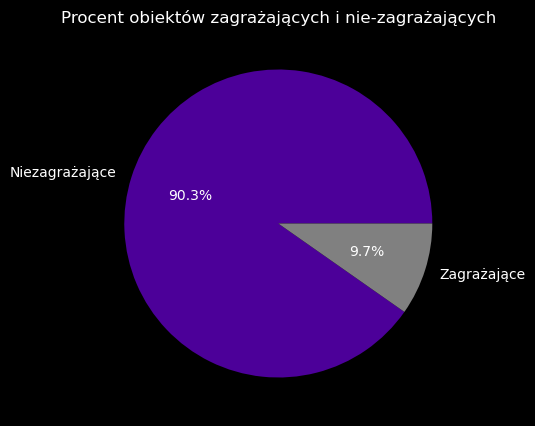

In [14]:
import matplotlib.pyplot as plt

# Assuming cosmos["hazardous"] contains the data
counts = cosmos["hazardous"].value_counts()
percentages = (counts / len(cosmos)) * 100

# Set the face color for the entire figure to black
plt.figure(figsize=(5, 5), facecolor='black')

# Plot the pie chart
pie = percentages.plot(kind='pie', autopct='%1.1f%%', colors=['#4C0099', '#808080'], labels=['Niezagrażające', 'Zagrażające'])

# Set title and labels color to white
plt.title('Procent obiektów zagrażających i nie-zagrażających', color='white')
plt.ylabel('')

# Set the face color of the pie chart area to black
plt.gca().set_facecolor('black')

# Set the text color for labels and percentages
for text in pie.texts:
    text.set_color('white')

# Display the plot
plt.show()


In [36]:
cosmos.describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


<Axes: >

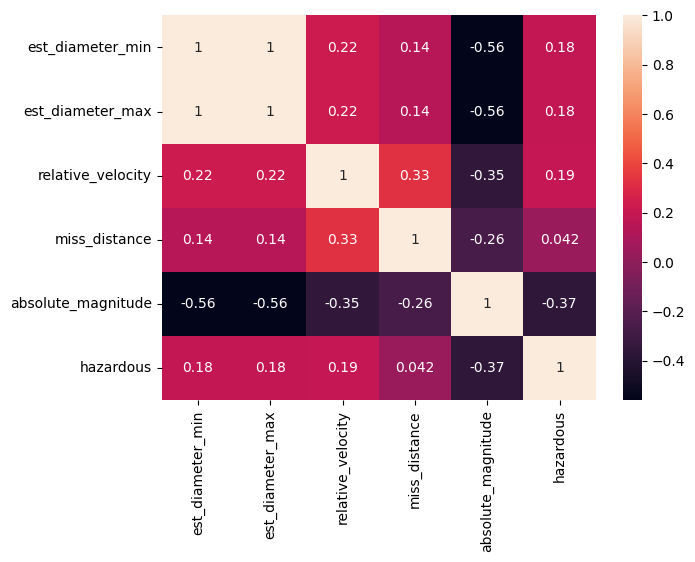

In [37]:
plt.figure(figsize=(7,5))
sns.heatmap(cosmos.corr(),annot=True)

In [38]:
cosmos.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True


In [39]:
X = cosmos.drop(['hazardous'], axis=1) #stworzenie grup x,y 
y = cosmos['hazardous']
print(X)
print(y)

       est_diameter_min  est_diameter_max  relative_velocity  miss_distance  \
0              1.198271          2.679415       13569.249224   5.483974e+07   
1              0.265800          0.594347       73588.726663   6.143813e+07   
2              0.722030          1.614507      114258.692129   4.979872e+07   
3              0.096506          0.215794       24764.303138   2.543497e+07   
4              0.255009          0.570217       42737.733765   4.627557e+07   
...                 ...               ...                ...            ...   
90831          0.026580          0.059435       52078.886692   1.230039e+07   
90832          0.016771          0.037501       46114.605073   5.432121e+07   
90833          0.031956          0.071456        7566.807732   2.840077e+07   
90834          0.007321          0.016370       69199.154484   6.869206e+07   
90835          0.039862          0.089133       27024.455553   5.977213e+07   

       absolute_magnitude  
0                   16.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=0, stratify=y) #podzial na zbior testowy (podział zależy od ilości danych, tu 90M wierszy, ale tylko 10% )
#poczytać o imbalanced DS (zduplikowanie y, crossvalidation, zbior walidacyjny, inne modele), stratify uwzględnia proporcje populacji 

In [41]:
model = LogisticRegression().fit(X_train, y_train)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(59043, 5)
(31793, 5)
(59043,)
(31793,)


In [43]:
y_train.value_counts()

hazardous
False    53297
True      5746
Name: count, dtype: int64

In [44]:
model.coef_, model.feature_names_in_ #Obliczenie współczynnikow 

(array([[ 1.12999607e-03,  2.52674803e-03,  2.22136448e-05,
         -1.63854187e-09, -1.52490215e-01]]),
 array(['est_diameter_min', 'est_diameter_max', 'relative_velocity',
        'miss_distance', 'absolute_magnitude'], dtype=object))

In [45]:
model.intercept_ #obliczenie B0

array([-0.00505033])

In [46]:
pred_train = model.predict(X_train) #model.predict zwraca przynależność do klasy


In [47]:
pd.Series(pred_train).value_counts()

False    58738
True       305
Name: count, dtype: int64

In [48]:
pred_train_proba = model.predict_proba(X_train) #prawdopodobienstwo przynaleznosci do klasy ( ze true i że false)

In [49]:
pred_train_proba

array([[0.91351781, 0.08648219],
       [0.85547864, 0.14452136],
       [0.81760608, 0.18239392],
       ...,
       [0.9251368 , 0.0748632 ],
       [0.82298474, 0.17701526],
       [0.94467307, 0.05532693]])

In [50]:
accuracy_score(y_train,pred_train)

0.9002591331741273

In [51]:
from sklearn.metrics import confusion_matrix

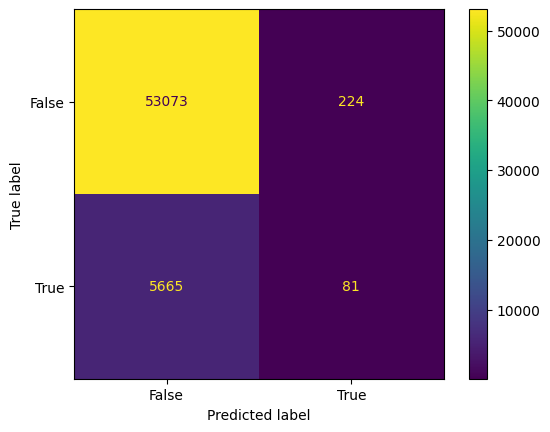

In [53]:
ConfusionMatrixDisplay.from_predictions(y_train,pred_train)

In [56]:
print(classification_report(y_train,pred_train))

              precision    recall  f1-score   support

       False       0.90      1.00      0.95     53297
        True       0.27      0.01      0.03      5746

    accuracy                           0.90     59043
   macro avg       0.58      0.50      0.49     59043
weighted avg       0.84      0.90      0.86     59043



In [ ]:
print(y_train.shape)

(59043,)


In [27]:
pred_train_proba_positive=pred_train_proba[:, 1] # Tylko prawdopodobieństwo że klasa 1 

In [42]:
roc_auc_score(y_train,pred_train_proba_positive)

0.8202397533511141

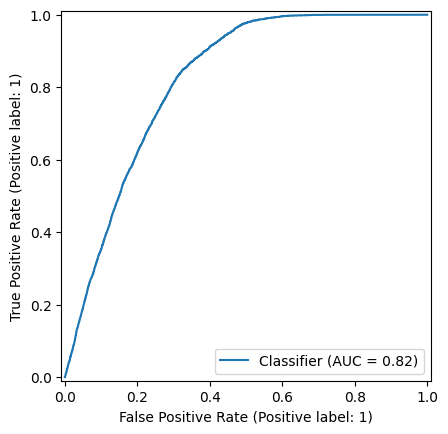

In [49]:
from sklearn.metrics import RocCurveDisplay, roc_curve ## roc_curve - wartości tpr, fpr, thresholds
RocCurveDisplay.from_predictions(y_train,pred_train_proba_positive)